# Automatic Detection of Sleep Apneas in Children -- LOO approach


### In this tutorial, there will be implemented three models to automatically detect apnea events: BiLSTM, ML ensemble and an hybrid approach coupling the previous ones.

In [1]:
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import os, sys
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import LeaveOneOut
from datetime import datetime, timedelta
import random

notebook_dir = os.getcwd()
parent_dir = os.path.join(notebook_dir, '..')
sys.path.append(parent_dir)
from aether.rnn_bilstm import BILSTMModel
from aether.respiratory_dataset_loo import RespiratoryDatasetLOO
from aether.utils_rnn import collate_fn_loo, evaluate_model, find_best_threshold, calculate_metrics


### Load data and extract only the relevant features from the data features. To understand which features are relevant see the feat_selection tutorial.

In [8]:
#Execute this when you have your files with the correct data
with open('resp_events.pkl', 'rb') as f:
    resp_events = pickle.load(f)


print('N. resp events', len(resp_events))
resp_labels=np.load("resp_labels.npy") 
print('N. resp labels', len(resp_labels))
resp_feat=np.load("resp_feat.npy") 
print('N. features', len(resp_feat[0]))

# extract only feautures 0,3,7,9 (important one) 
df = pd.DataFrame(resp_feat)
idx_sel = [0, 3, 7, 9]
resp_feat_sel = df.iloc[:, idx_sel]
resp_feat  = resp_feat_sel.to_numpy()
print('N. features', len(resp_feat[0]))


with open('times_tot.pkl', 'rb') as f:
    times_tot=pickle.load(f) 
print('N. times total', len(times_tot))

with open('resp_int.pkl', 'rb') as f:
    resp_int_tot=pickle.load(f) 
print('N. resp intervals', len(resp_int_tot))


id_patients=np.load("id_list.npy") 
print('N. id labels', len(id_patients))

id_times=np.load("id_list_times.npy") 
print('N. id times', len(id_times))

N. resp events 17414
N. resp labels 10000
N. features 10
N. features 4
N. times total 1584004
N. resp intervals 17414
N. id labels 17414
N. id times 1584004


In [2]:
# Generate dummy data to perform simulation
n_events = 10000 
n_features = 10 
n_patients = 10
events_per_patient = n_events // n_patients

patient_ids_per_chunk = np.repeat(np.arange(n_patients), events_per_patient)

# param for non-consecutive gaps
min_gap = 10
max_gap = 100

# unbalanced ratio (80% normal events (0), 20% apnea events (1))
non_apnea_ratio = 0.8
n_nonapnea = int(n_events * non_apnea_ratio)
n_apnea = n_events - n_nonapnea

print(f"Generation of {n_events} events")
print(f"Non apnea Events (Class 0): {n_nonapnea} (80%)")
print(f"Apnea Events (Class 1): {n_apnea} (20%)")

# generate labels and shuffle them
labels_non_apnea = np.zeros(n_nonapnea, dtype=int)
labels_apnea = np.ones(n_apnea, dtype=int)
resp_labels = np.concatenate([labels_non_apnea, labels_apnea])

np.random.shuffle(resp_labels)


# Generate random features for all events using a normal distribution
# to simulate real data
resp_feat = np.random.randn(n_events, n_features).astype(np.float32)

idx_sel = [0, 3, 7, 9]
resp_feat = resp_feat[:, idx_sel]
print('N. features', len(resp_feat[0]))

# Generate random respiratory events value with different length 
resp_events = []
# define an interval for the lenghts of this respiratory events
min_len = 22 
max_len = 35 

for i in range(n_events):
    length = np.random.randint(min_len, max_len + 1)
    
    # generate a temporal serie: sin + noise to simulate our normalized values
    t = np.linspace(0, 2 * np.pi, length)
    
    # for apnea events the signal should be more flat (less nopise)
    if resp_labels[i] == 1:
        signal = 0.1 * np.sin(t * 2) + 0.5 + 0.05 * np.random.randn(length)
    else:
        signal = 0.5 * np.sin(t * 3) + 1.0 + 0.1 * np.random.randn(length)

    resp_events.append(signal.astype(np.float32))

resp_int = []
current_global_index = 0
t_format = '%H:%M:%S.%f'
id_patients = []  
id_times = [] 

for i in range(n_events):
    length = len(resp_events[i])
    label = resp_labels[i]
    patient_id = patient_ids_per_chunk[i]

    start = current_global_index
    end = current_global_index + length - 1

    id_patients.append(patient_id)
    id_times.extend([patient_id] * length)
    resp_int.append([start, end])
    
    current_global_index = end + 1
    
    # add the gap (to have non consecutive intervals)
    if i < n_events - 1:
        gap = random.randint(min_gap, max_gap)
        current_global_index += gap

id_patients = np.array(id_patients, dtype=int)
id_times = np.array(id_times, dtype=int)
total_samples = current_global_index
print(f"Total sequential samples derived: {total_samples}")
print(f"Total respiration intervals: {len(resp_int)}")

# generate the related timestamps for all the sample data

sampling_rate= 1
start_time = datetime.now()
time_data = [(start_time + timedelta(seconds=i / sampling_rate)).strftime(t_format)[:-3] for i in range(total_samples+1000)]

duration_minutes = total_samples / sampling_rate / 60
print(f"Total time duration simulated: {duration_minutes:.2f} minutes")



Generation of 10000 events
Non apnea Events (Class 0): 8000 (80%)
Apnea Events (Class 1): 2000 (20%)
N. features 4
Total sequential samples derived: 837441
Total respiration intervals: 10000
Total time duration simulated: 13957.35 minutes


# BiLSTM
### Implementation of the LOO approach for the BiLSTM case.


BiLSTM MODEL
Training on 9000 samples, Testing on 1000 samples (Patient 0)
Testing Accuracy: 1.00
Best threshold based on F1-score: 0.9997
Optimal threshold: 0.9997

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       811
       Apnea       1.00      1.00      1.00       189

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[811   0]
 [  0 189]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


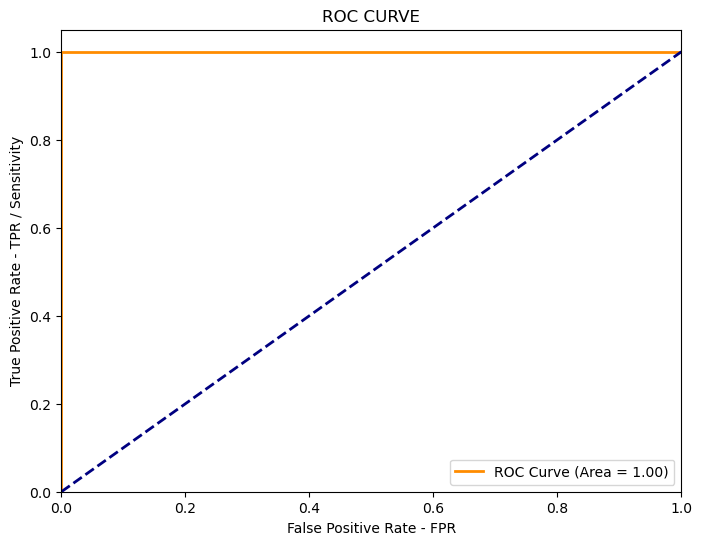


Training on 9000 samples, Testing on 1000 samples (Patient 1)
Epoch 1/50 - Loss: 0.8844, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7326, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.6909, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.3338, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.1792, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.1051, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0547, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0314, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0206, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0151, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0118, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0096, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0080, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0069, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0061, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0054, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0049, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0044, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0040, Learning rate: 0.0

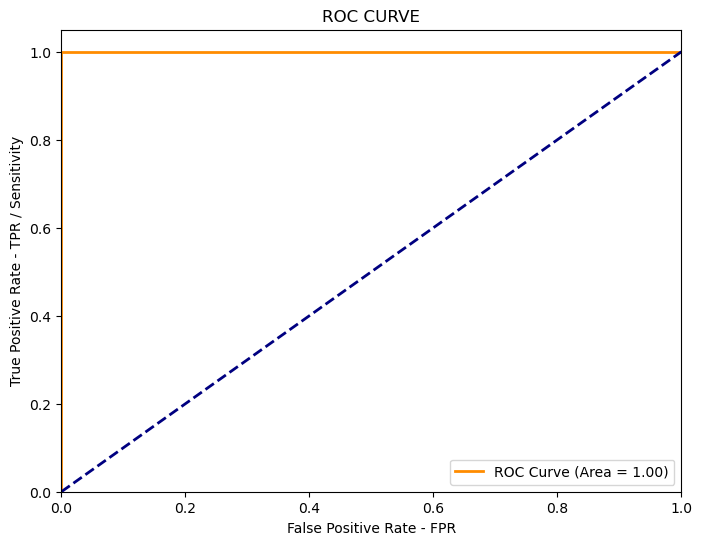


Training on 9000 samples, Testing on 1000 samples (Patient 2)
Epoch 1/50 - Loss: 0.9144, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7287, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.4930, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.1964, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.1111, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.0562, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0280, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0173, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0123, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0092, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0074, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0062, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0052, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0046, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0040, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0036, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0033, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0030, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0028, Learning rate: 0.0

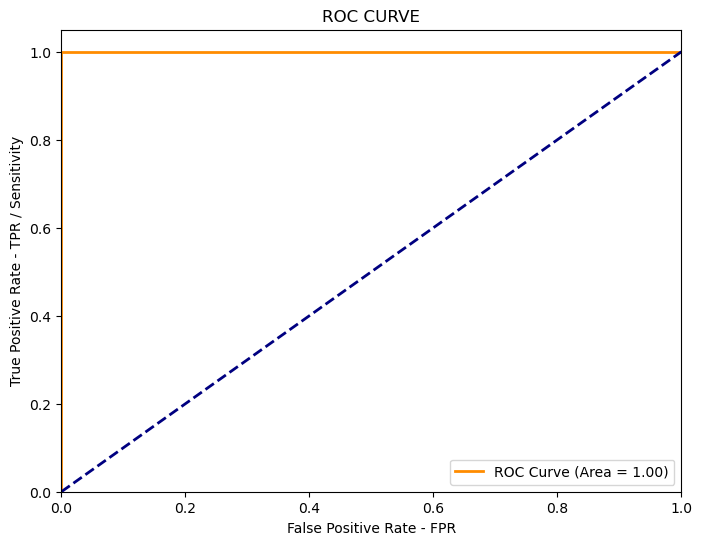


Training on 9000 samples, Testing on 1000 samples (Patient 3)
Epoch 1/50 - Loss: 0.9639, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7470, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.7205, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.6715, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.3264, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.1146, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0504, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0298, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0206, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0153, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0123, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0100, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0086, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0074, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0065, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0057, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0052, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0047, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0043, Learning rate: 0.0

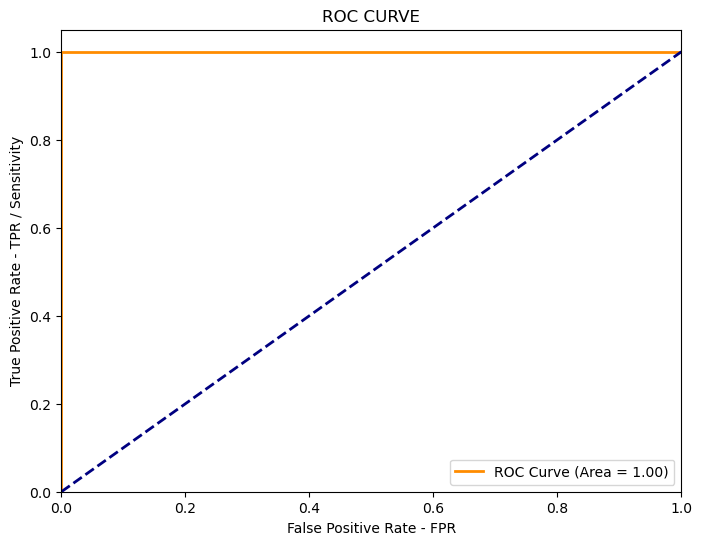


Training on 9000 samples, Testing on 1000 samples (Patient 4)
Epoch 1/50 - Loss: 0.9085, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7264, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.6892, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.3026, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.1545, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.0770, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0357, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0190, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0127, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0096, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0076, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0064, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0055, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0048, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0042, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0037, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0034, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0031, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0028, Learning rate: 0.0

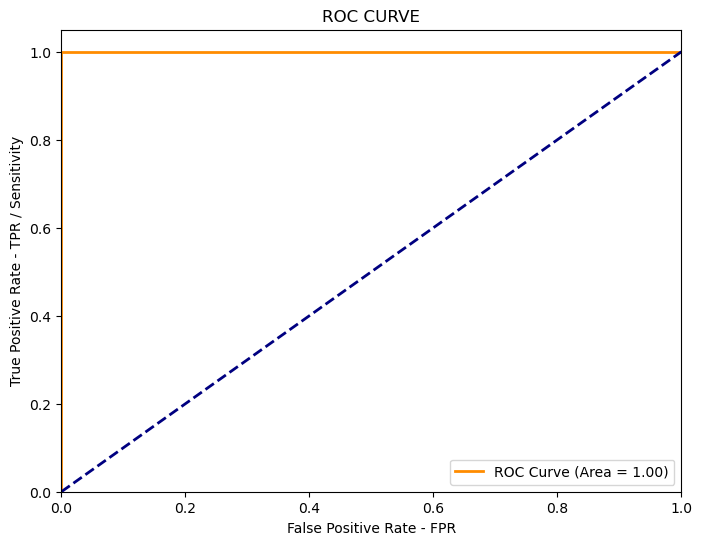


Training on 9000 samples, Testing on 1000 samples (Patient 5)
Epoch 1/50 - Loss: 0.9960, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7436, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.7258, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.7180, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.5119, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.1440, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0613, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0324, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0210, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0156, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0122, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0099, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0083, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0073, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0062, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0055, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0050, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0045, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0040, Learning rate: 0.0

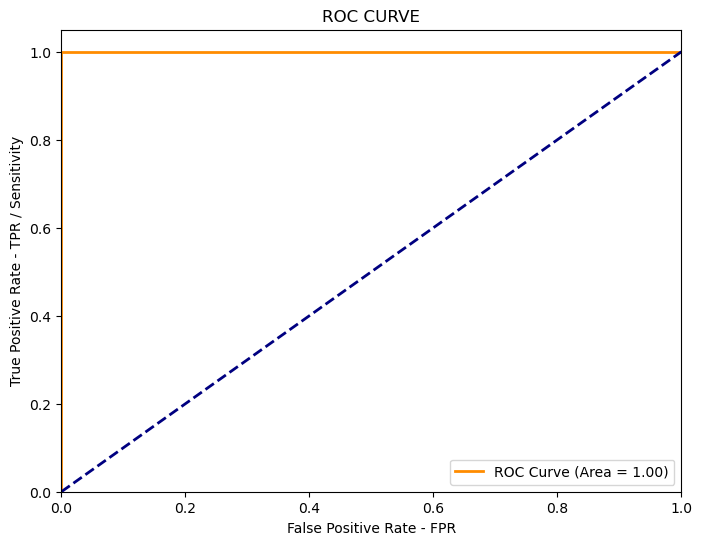


Training on 9000 samples, Testing on 1000 samples (Patient 6)
Epoch 1/50 - Loss: 0.8984, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7224, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.5208, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.2180, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.1343, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.0788, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0463, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0287, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0192, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0136, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0103, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0084, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0068, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0058, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0050, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0044, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0040, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0036, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0033, Learning rate: 0.0

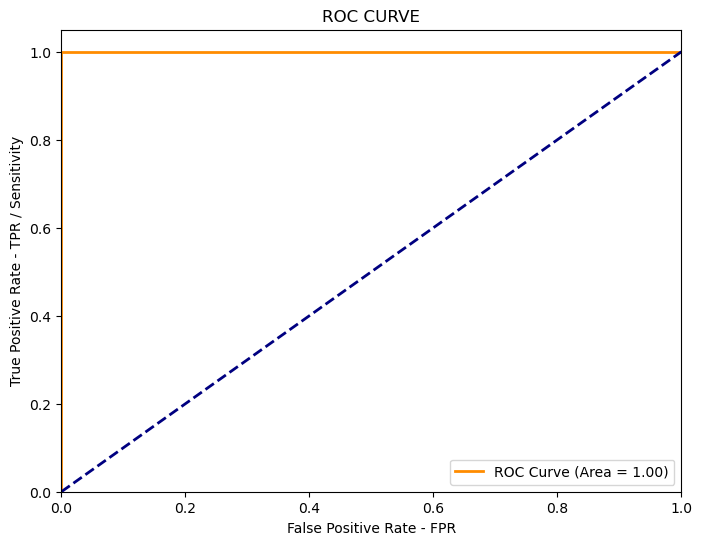


Training on 9000 samples, Testing on 1000 samples (Patient 7)
Epoch 1/50 - Loss: 0.9038, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7236, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.5900, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.2299, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.1387, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.0835, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0445, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0251, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0166, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0123, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0096, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0078, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0066, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0057, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0050, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0045, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0040, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0036, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0033, Learning rate: 0.0

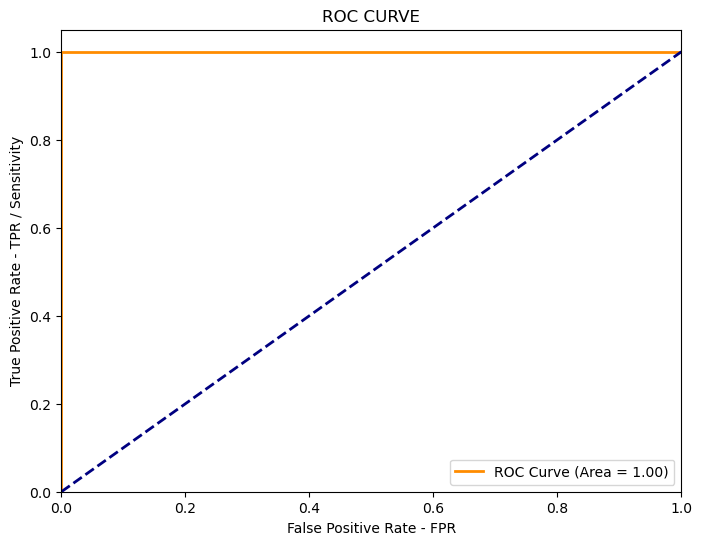


Training on 9000 samples, Testing on 1000 samples (Patient 8)
Epoch 1/50 - Loss: 0.9146, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7301, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.6408, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.2614, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.1526, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.0790, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0375, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0221, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0151, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0113, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0089, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0074, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0062, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0054, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0046, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0042, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0037, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0034, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0031, Learning rate: 0.0

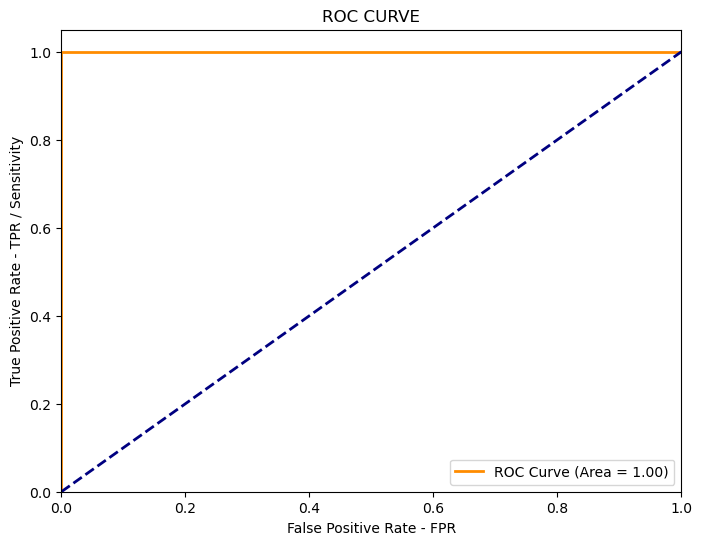


Training on 9000 samples, Testing on 1000 samples (Patient 9)
Epoch 1/50 - Loss: 0.9766, Learning rate: 0.0001
Epoch 2/50 - Loss: 0.7403, Learning rate: 0.0001
Epoch 3/50 - Loss: 0.5224, Learning rate: 0.0001
Epoch 4/50 - Loss: 0.2035, Learning rate: 0.0001
Epoch 5/50 - Loss: 0.1363, Learning rate: 0.0001
Epoch 6/50 - Loss: 0.0929, Learning rate: 0.0001
Epoch 7/50 - Loss: 0.0513, Learning rate: 0.0001
Epoch 8/50 - Loss: 0.0292, Learning rate: 0.0001
Epoch 9/50 - Loss: 0.0186, Learning rate: 0.0001
Epoch 10/50 - Loss: 0.0133, Learning rate: 0.0001
Epoch 11/50 - Loss: 0.0102, Learning rate: 0.0001
Epoch 12/50 - Loss: 0.0083, Learning rate: 0.0001
Epoch 13/50 - Loss: 0.0069, Learning rate: 0.0001
Epoch 14/50 - Loss: 0.0059, Learning rate: 0.0001
Epoch 15/50 - Loss: 0.0052, Learning rate: 0.0001
Epoch 16/50 - Loss: 0.0046, Learning rate: 0.0001
Epoch 17/50 - Loss: 0.0041, Learning rate: 0.0001
Epoch 18/50 - Loss: 0.0037, Learning rate: 0.0001
Epoch 19/50 - Loss: 0.0033, Learning rate: 0.0

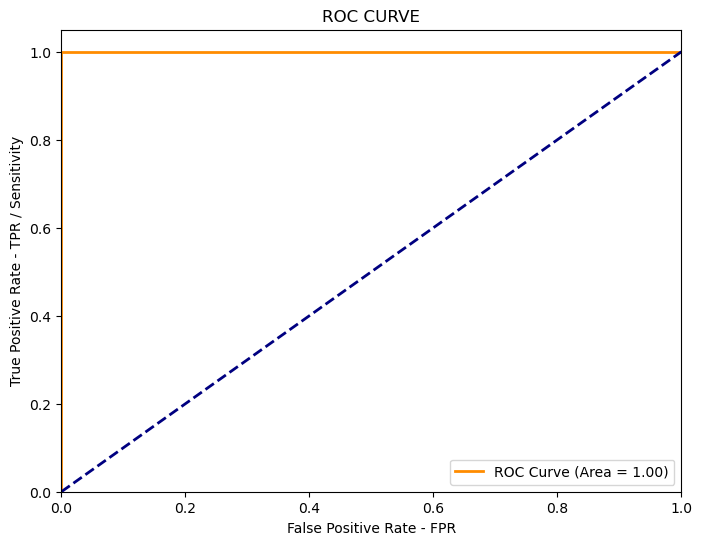

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\n" + "="*70)
print("BiLSTM MODEL")
print("="*70)
full_dataset = RespiratoryDatasetLOO(resp_events, resp_labels, id_patients)
patient_ids = full_dataset.patients_ids

# get unique patient ids
unique_ids = np.unique(patient_ids)

results = []

loo = LeaveOneOut()


for train_patient_indices, test_patient_index in loo.split(unique_ids):
    # Get patient IDs for training and testing
    train_patient_ids = unique_ids[train_patient_indices]
    test_patient_id = unique_ids[test_patient_index][0]  # Single ID for test

    # Get dataset indices for training and testing
    train_indices = [i for i, pid in enumerate(patient_ids) if pid in train_patient_ids]
    test_indices = [i for i, pid in enumerate(patient_ids) if pid == test_patient_id]


    # Get labels of training samples
    train_labels = [full_dataset[i][1] for i in train_indices]
    
    # Compute class weights for training set
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    train_sample_weights = [class_weights[label] for label in train_labels]
    # Create weighted sampler for training
    train_sampler = WeightedRandomSampler(weights=train_sample_weights, num_samples=len(train_indices), replacement=True)
    # Create DataLoaders
    train_dataset = Subset(full_dataset, train_indices)
    test_dataset = Subset(full_dataset, test_indices)
    train_loader = DataLoader(train_dataset, batch_size=128, sampler=train_sampler, collate_fn=collate_fn_loo)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, collate_fn=collate_fn_loo)
    print(f"Training on {len(train_indices)} samples, Testing on {len(test_indices)} samples (Patient {test_patient_id})")
    # Train and evaluate your model using train_loader and test_loader

    # MODEL SETUP
    bilstm_model = BILSTMModel(input_size=1).to(device)
    optimizer = optim.Adam(bilstm_model.parameters(), lr=0.0001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

    # Calculate weights for BCELoss
    class_0_count = class_counts[0]
    class_1_count = class_counts[1]
    # The weight for the minority class is the ratio of the majority class to the minority class
    pos_weight = torch.tensor([class_0_count / class_1_count]).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    file_path = 'bilstm_id{}.pth'.format(test_patient_id)
    if os.path.exists(file_path):
        bilstm_model.load_state_dict(torch.load(file_path, weights_only=True))
    else:
        # TRAINING LOOP
        num_epochs = 50
        for epoch in range(num_epochs):
            bilstm_model.train()
            total_loss = 0.0
            for batch in train_loader:
                sequences, labels, seq_len_batch, _ = batch  # Ignore patient IDs during training
                sequences, labels = sequences.to(device), labels.to(device)
                optimizer.zero_grad()

                X_batch = sequences.unsqueeze(-1)
                outputs = bilstm_model(X_batch, seq_len_batch)
                loss = criterion(outputs.squeeze().to(device), labels.float())
                loss.backward()
                optimizer.step()
                total_loss += loss.item()/float(seq_len_batch.size(0))

            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f}, Learning rate: {current_lr}")
        file_path= 'bilstm_id{}.pth'.format(test_patient_id)
        torch.save(bilstm_model.state_dict(), file_path)

    bilstm_model.eval()

    test_accuracy, y_pred, y_true, y_probs = evaluate_model(bilstm_model, test_loader, device)
    print(f"Testing Accuracy: {test_accuracy:.2f}")

    lstm_probs = np.array(y_probs)

    best_thresh = find_best_threshold(np.array(y_true), lstm_probs, method='f1')
    print(f"Optimal threshold: {best_thresh:.4f}")

    # Apply threshold to new predictions
    y_pred = (lstm_probs >= best_thresh).astype(int)

    metrics_dict = calculate_metrics(y_true, y_pred, lstm_probs)

    results.append({"patient_id": test_patient_id, 
                    "test_accuracy": metrics_dict['accuracy'], 
                    'tpr': metrics_dict['sensitivity'], 
                    'tnr': metrics_dict['specificity'], 
                    'ppv': metrics_dict['ppv'], 
                    'npv': metrics_dict['npv'], 
                    'auc-roc': metrics_dict['auc_roc'], 
                    'f1': metrics_dict['f1_score'], 
                    'pr_auc': metrics_dict['auc_pr']})



# ML Ensemble
### Training and testing of the model using the LOO approach


ML ENSEMBLE
PATIENT 0
Best threshold based on F1-score: 0.3259
Optimal threshold: 0.3259

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.85      0.05      0.10       811
       Apnea       0.19      0.96      0.32       189

    accuracy                           0.22      1000
   macro avg       0.52      0.51      0.21      1000
weighted avg       0.73      0.22      0.14      1000


--- Confusion Matrix ---
[[ 41 770]
 [  7 182]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0506
Negative Predictive Value (NPV): 0.8542
Sensitivity (Recall/TPR): 0.9630
Precision (PPV): 0.1912
Accuracy: 0.2230
F1 Score: 0.3190

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.5180
Precision-Recall AUC Score: 0.1987


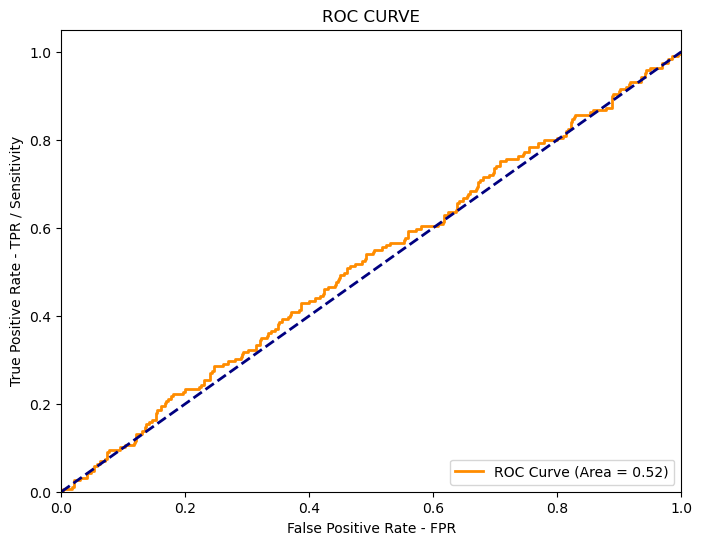


PATIENT 1
Best threshold based on F1-score: 0.3093
Optimal threshold: 0.3093

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.93      0.02      0.03       799
       Apnea       0.20      1.00      0.34       201

    accuracy                           0.21      1000
   macro avg       0.57      0.51      0.18      1000
weighted avg       0.78      0.21      0.09      1000


--- Confusion Matrix ---
[[ 13 786]
 [  1 200]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0163
Negative Predictive Value (NPV): 0.9286
Sensitivity (Recall/TPR): 0.9950
Precision (PPV): 0.2028
Accuracy: 0.2130
F1 Score: 0.3370

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.5058
Precision-Recall AUC Score: 0.2038


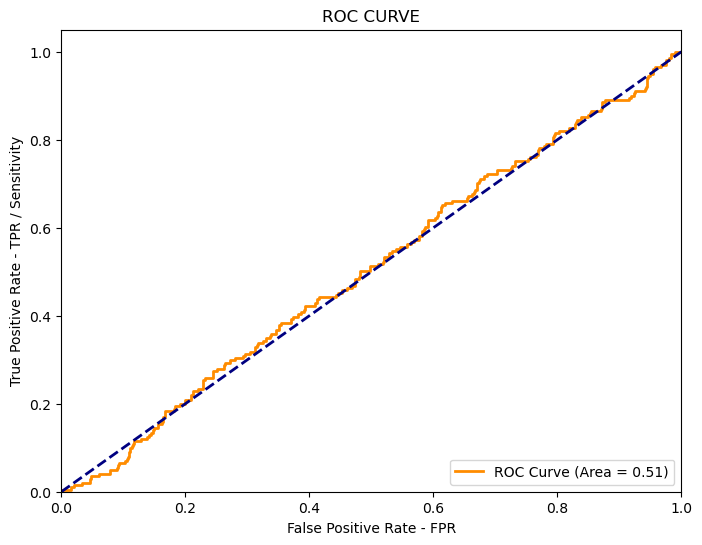


PATIENT 2
Best threshold based on F1-score: 0.2825
Optimal threshold: 0.2825

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.00      0.01       788
       Apnea       0.21      1.00      0.35       212

    accuracy                           0.21      1000
   macro avg       0.61      0.50      0.18      1000
weighted avg       0.83      0.21      0.08      1000


--- Confusion Matrix ---
[[  3 785]
 [  0 212]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0038
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2126
Accuracy: 0.2150
F1 Score: 0.3507

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.5071
Precision-Recall AUC Score: 0.2182


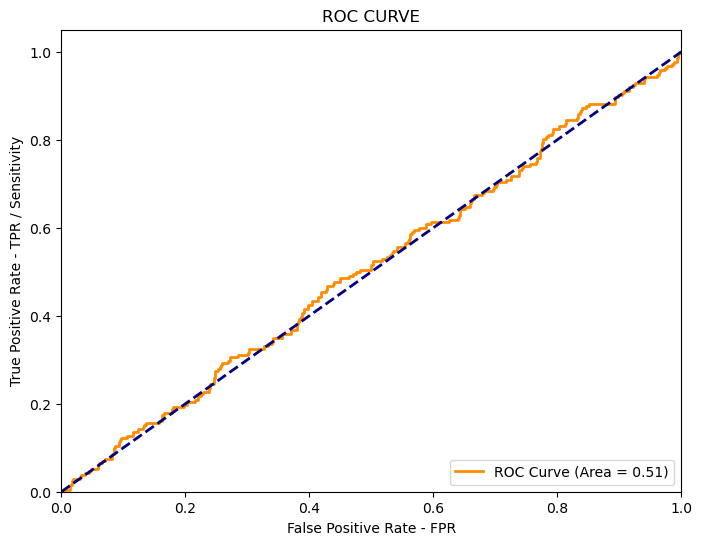


PATIENT 3
Best threshold based on F1-score: 0.3320
Optimal threshold: 0.3320

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.89      0.06      0.11       804
       Apnea       0.20      0.97      0.33       196

    accuracy                           0.24      1000
   macro avg       0.54      0.51      0.22      1000
weighted avg       0.75      0.24      0.16      1000


--- Confusion Matrix ---
[[ 48 756]
 [  6 190]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0597
Negative Predictive Value (NPV): 0.8889
Sensitivity (Recall/TPR): 0.9694
Precision (PPV): 0.2008
Accuracy: 0.2380
F1 Score: 0.3327

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4978
Precision-Recall AUC Score: 0.1937


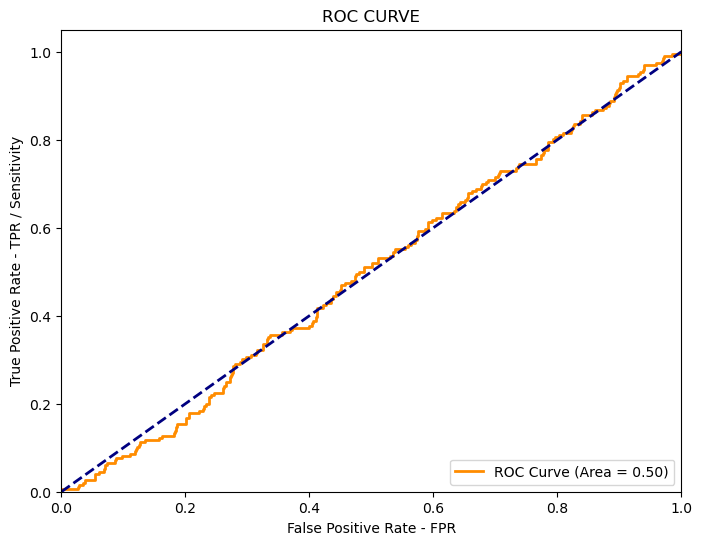


PATIENT 4
Best threshold based on F1-score: 0.3436
Optimal threshold: 0.3436

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.87      0.10      0.18       792
       Apnea       0.22      0.94      0.35       208

    accuracy                           0.27      1000
   macro avg       0.54      0.52      0.26      1000
weighted avg       0.73      0.27      0.21      1000


--- Confusion Matrix ---
[[ 78 714]
 [ 12 196]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0985
Negative Predictive Value (NPV): 0.8667
Sensitivity (Recall/TPR): 0.9423
Precision (PPV): 0.2154
Accuracy: 0.2740
F1 Score: 0.3506

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.5272
Precision-Recall AUC Score: 0.2202


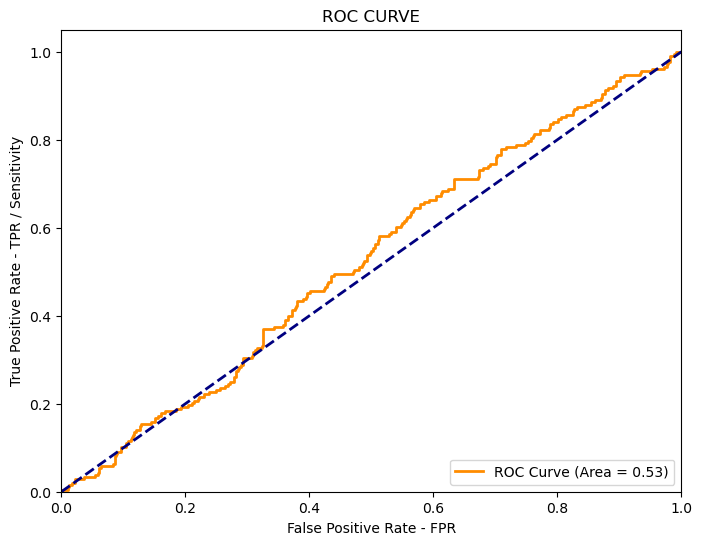


PATIENT 5
Best threshold based on F1-score: 0.3343
Optimal threshold: 0.3343

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.86      0.07      0.13       797
       Apnea       0.21      0.96      0.34       203

    accuracy                           0.25      1000
   macro avg       0.53      0.51      0.24      1000
weighted avg       0.73      0.25      0.17      1000


--- Confusion Matrix ---
[[ 56 741]
 [  9 194]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0703
Negative Predictive Value (NPV): 0.8615
Sensitivity (Recall/TPR): 0.9557
Precision (PPV): 0.2075
Accuracy: 0.2500
F1 Score: 0.3409

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4895
Precision-Recall AUC Score: 0.2016


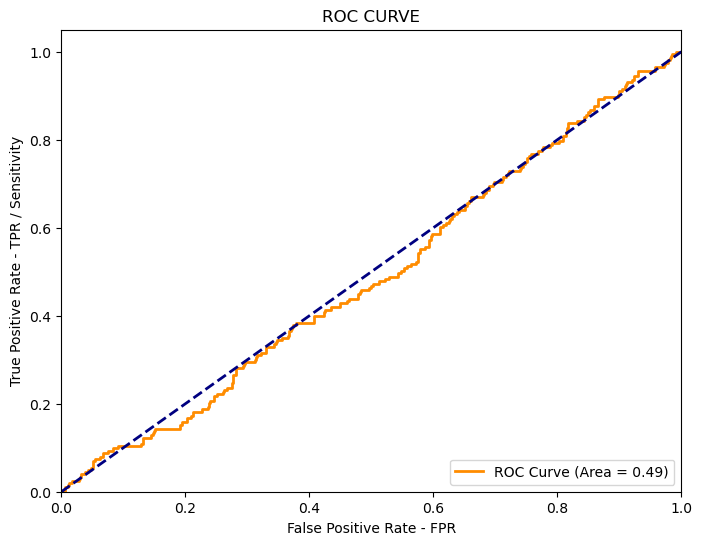


PATIENT 6
Best threshold based on F1-score: 0.3171
Optimal threshold: 0.3171

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.90      0.02      0.05       801
       Apnea       0.20      0.99      0.33       199

    accuracy                           0.22      1000
   macro avg       0.55      0.51      0.19      1000
weighted avg       0.76      0.22      0.10      1000


--- Confusion Matrix ---
[[ 19 782]
 [  2 197]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0237
Negative Predictive Value (NPV): 0.9048
Sensitivity (Recall/TPR): 0.9899
Precision (PPV): 0.2012
Accuracy: 0.2160
F1 Score: 0.3345

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4859
Precision-Recall AUC Score: 0.1986


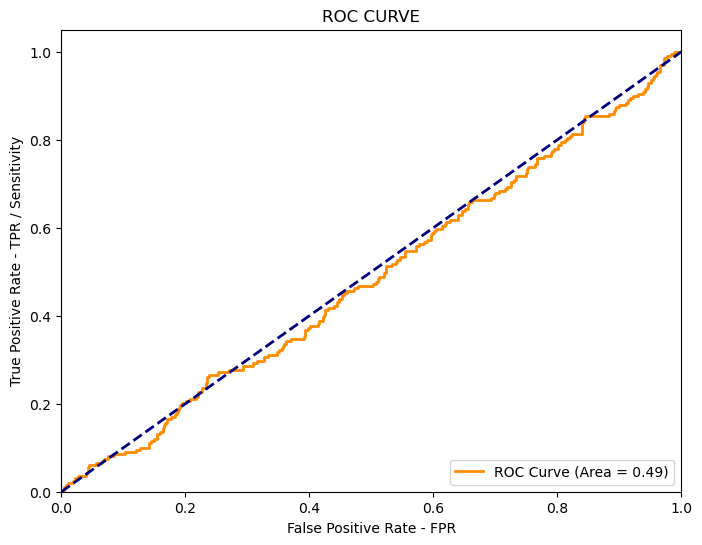


PATIENT 7
Best threshold based on F1-score: 0.2994
Optimal threshold: 0.2994

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.00      0.01       812
       Apnea       0.19      1.00      0.32       188

    accuracy                           0.19      1000
   macro avg       0.59      0.50      0.16      1000
weighted avg       0.85      0.19      0.07      1000


--- Confusion Matrix ---
[[  4 808]
 [  0 188]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0049
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.1888
Accuracy: 0.1920
F1 Score: 0.3176

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4757
Precision-Recall AUC Score: 0.1848


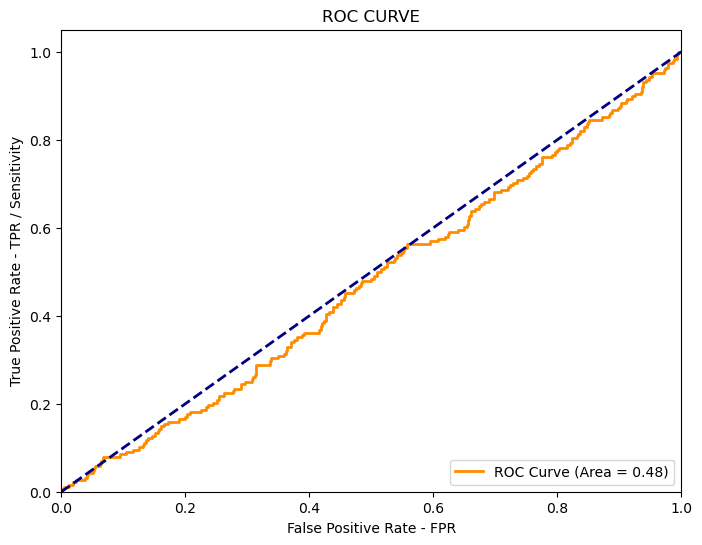


PATIENT 8
Best threshold based on F1-score: 0.3025
Optimal threshold: 0.3025

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      0.02      0.03       800
       Apnea       0.20      1.00      0.34       200

    accuracy                           0.21      1000
   macro avg       0.60      0.51      0.18      1000
weighted avg       0.84      0.21      0.09      1000


--- Confusion Matrix ---
[[ 13 787]
 [  0 200]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0163
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 0.2026
Accuracy: 0.2130
F1 Score: 0.3370

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4985
Precision-Recall AUC Score: 0.1909


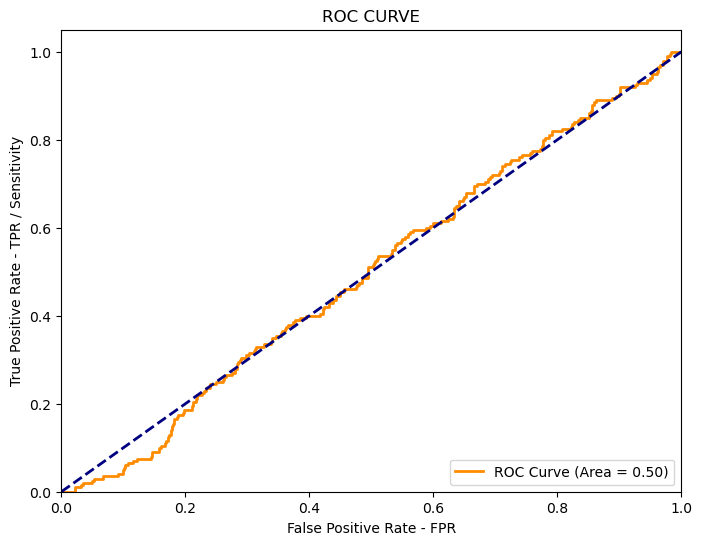


PATIENT 9
Best threshold based on F1-score: 0.3055
Optimal threshold: 0.3055

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       0.96      0.03      0.06       796
       Apnea       0.21      1.00      0.34       204

    accuracy                           0.23      1000
   macro avg       0.58      0.51      0.20      1000
weighted avg       0.81      0.23      0.12      1000


--- Confusion Matrix ---
[[ 25 771]
 [  1 203]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 0.0314
Negative Predictive Value (NPV): 0.9615
Sensitivity (Recall/TPR): 0.9951
Precision (PPV): 0.2084
Accuracy: 0.2280
F1 Score: 0.3447

--- Area Under Curve (AUC) ---
AUC-ROC Score: 0.4371
Precision-Recall AUC Score: 0.1853


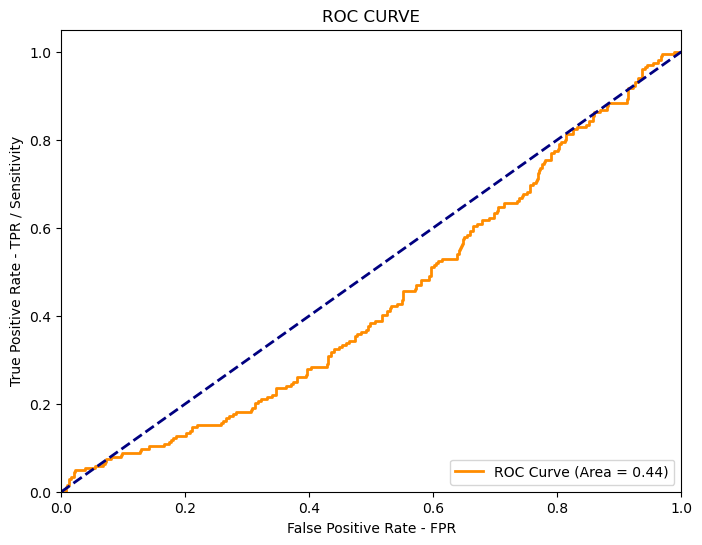

In [7]:
print("\n" + "="*70)
print("ML ENSEMBLE")
print("="*70)

results = []
loo = LeaveOneOut()



for train_patient_indices, test_patient_index in loo.split(unique_ids):
    # Get patient IDs for training and testing
    train_patient_ids = unique_ids[train_patient_indices]
    test_patient_id = unique_ids[test_patient_index][0]  # Single ID for test
    print('PATIENT', test_patient_id)
    # Get dataset indices for training and testing
    train_indices = [i for i, pid in enumerate(patient_ids) if pid in train_patient_ids]
    test_indices = [i for i, pid in enumerate(patient_ids) if pid == test_patient_id]

    # Get labels of training samples
    y_train = [resp_labels[i] for i in train_indices]
    class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
    
    num_zeros = 0
    num_ones = 0

    for label in train_labels:
        if label == 0:
            num_zeros += 1
        elif label == 1:
            num_ones += 1

    # Calculate pos_weight
    if num_ones > 0:
        pos_weight = num_zeros / num_ones
    else:
        pos_weight = 1.0 # Handle division by zero

    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}


    rf = RandomForestClassifier(class_weight=class_weight_dict, n_estimators=200, random_state=42, oob_score=True, min_samples_split=10, min_samples_leaf=1, max_features='log2', max_depth=20)
    xgb = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.01, scale_pos_weight=pos_weight, subsample=0.6, gamma=0.3, colsample_bytree=0.8)
    lgr = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced', C=np.float64(0.00407559644007287))
    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

    clf = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb), ('lgr', lgr), ('lda', lda)], voting='soft') # ('svm', svm)], voting='soft')
    X_train = [resp_feat[i] for i in train_indices]
    clf.fit(X_train, y_train)


    # TESTING LOOP
    X_test = [resp_feat[i] for i in test_indices]
    y_test = [resp_labels[i] for i in test_indices]

    y_pred = clf.predict(X_test)
    ml_probs = clf.predict_proba(X_test)[:,1]

    best_thresh = find_best_threshold(y_test, ml_probs, method='f1')
    print(f"Optimal threshold: {best_thresh:.4f}")

    # Apply threshold to new predictions
    y_pred = (np.array(ml_probs) >= best_thresh).astype(int) 

    metrics_dict = calculate_metrics(y_test, y_pred, ml_probs)
    
    results.append({"patient_id": test_patient_id, 
                    "test_accuracy": metrics_dict['accuracy'], 
                    'tpr': metrics_dict['sensitivity'], 
                    'tnr': metrics_dict['specificity'], 
                    'ppv': metrics_dict['ppv'], 
                    'npv': metrics_dict['npv'], 
                    'auc-roc': metrics_dict['auc_roc'], 
                    'f1': metrics_dict['f1_score'], 
                    'pr_auc': metrics_dict['auc_pr']})


# Hybrid model
Combine predictions of the three models to get a better prediction using information from all the models. We are combining them computing their average with equal weights.


HYBRID APPROACH
Training on 9000 samples, Testing on 1000 samples (Patient 0)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4242
Optimal threshold: 0.4242

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       811
       Apnea       1.00      1.00      1.00       189

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[811   0]
 [  0 189]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


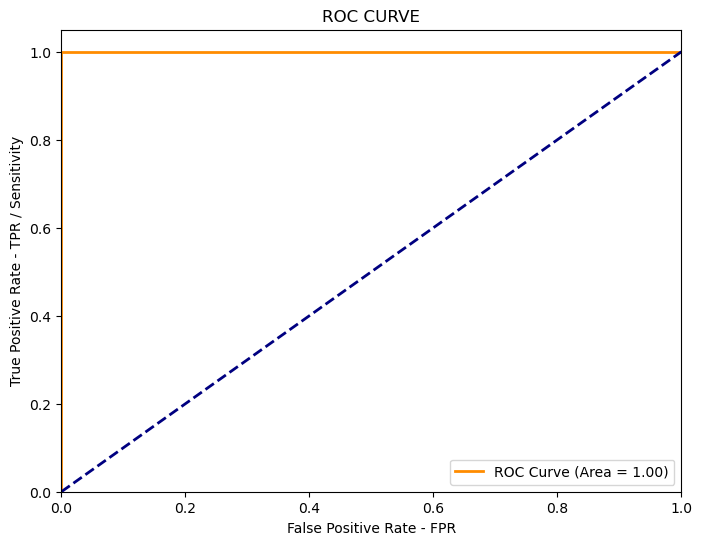


Training on 9000 samples, Testing on 1000 samples (Patient 1)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4422
Optimal threshold: 0.4422

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       799
       Apnea       1.00      1.00      1.00       201

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[799   0]
 [  0 201]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


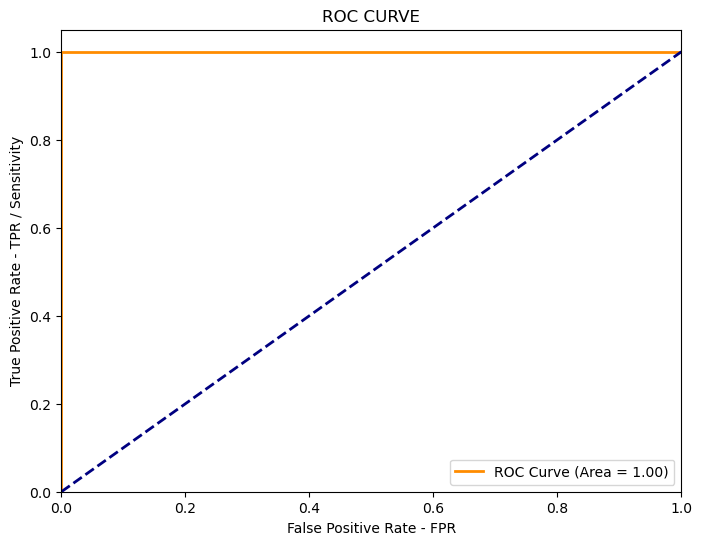


Training on 9000 samples, Testing on 1000 samples (Patient 2)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4269
Optimal threshold: 0.4269

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       788
       Apnea       1.00      1.00      1.00       212

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[788   0]
 [  0 212]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


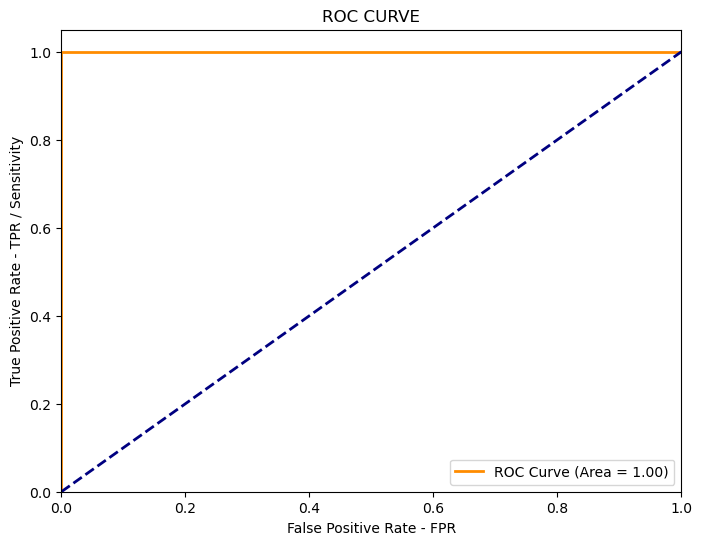


Training on 9000 samples, Testing on 1000 samples (Patient 3)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4207
Optimal threshold: 0.4207

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       804
       Apnea       1.00      1.00      1.00       196

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[804   0]
 [  0 196]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


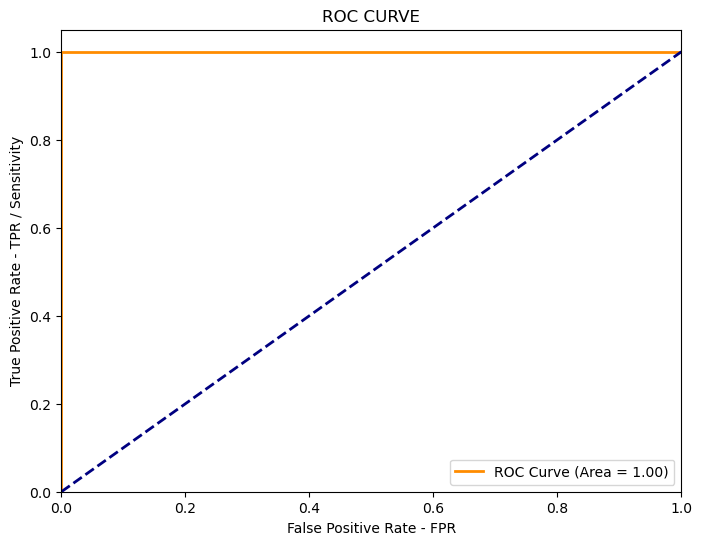


Training on 9000 samples, Testing on 1000 samples (Patient 4)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4433
Optimal threshold: 0.4433

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       792
       Apnea       1.00      1.00      1.00       208

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[792   0]
 [  0 208]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


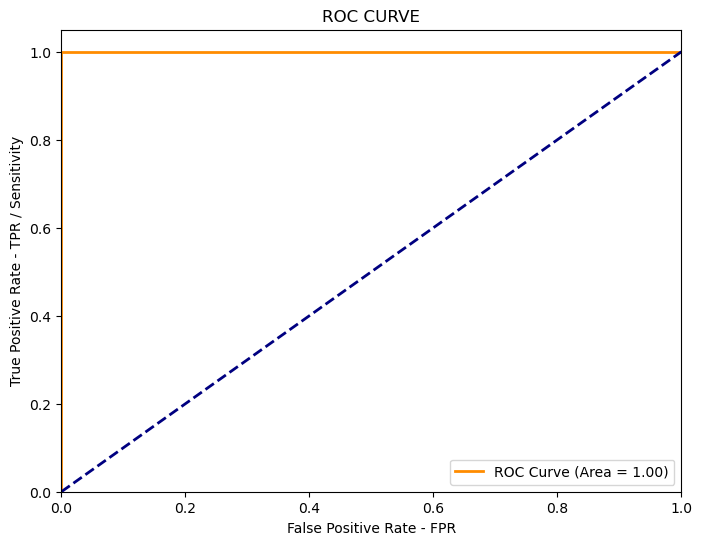


Training on 9000 samples, Testing on 1000 samples (Patient 5)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4338
Optimal threshold: 0.4338

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       797
       Apnea       1.00      1.00      1.00       203

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[797   0]
 [  0 203]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


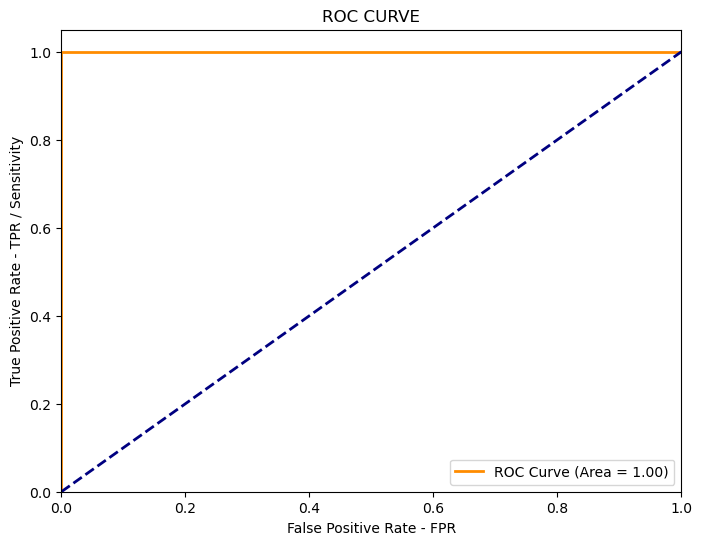


Training on 9000 samples, Testing on 1000 samples (Patient 6)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4443
Optimal threshold: 0.4443

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       801
       Apnea       1.00      1.00      1.00       199

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[801   0]
 [  0 199]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


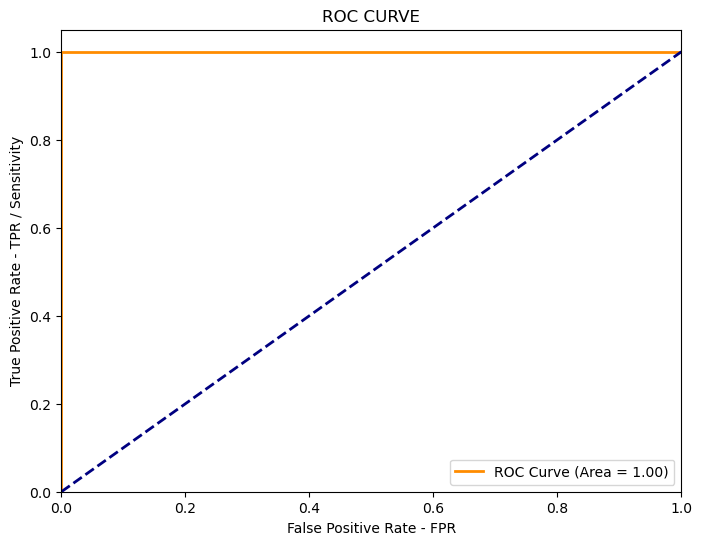


Training on 9000 samples, Testing on 1000 samples (Patient 7)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4400
Optimal threshold: 0.4400

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       812
       Apnea       1.00      1.00      1.00       188

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[812   0]
 [  0 188]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


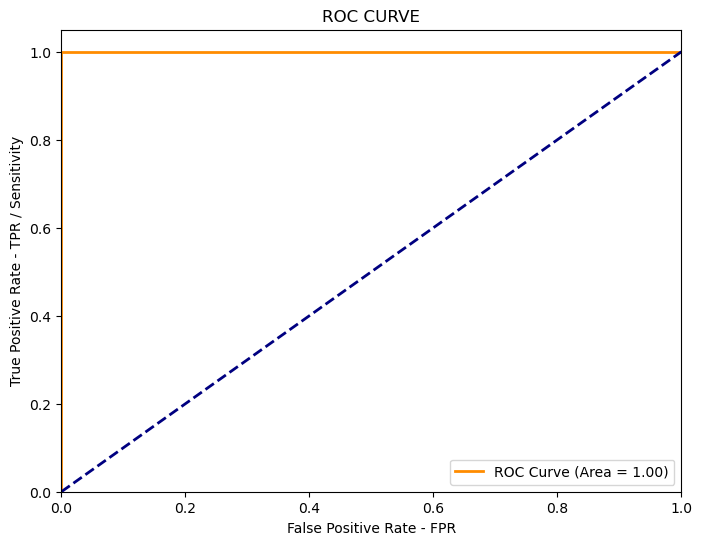


Training on 9000 samples, Testing on 1000 samples (Patient 8)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4423
Optimal threshold: 0.4423

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       800
       Apnea       1.00      1.00      1.00       200

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[800   0]
 [  0 200]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


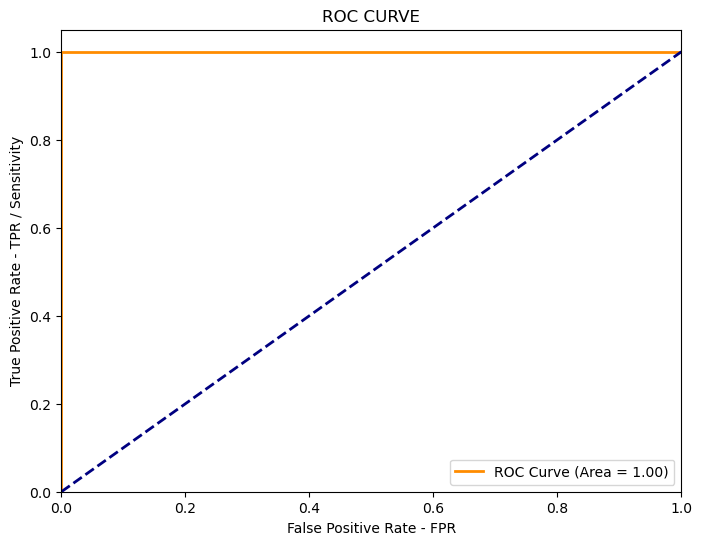


Training on 9000 samples, Testing on 1000 samples (Patient 9)
test Bilstm model
###############hybrid approach ##################
Meta-features shape: (1000, 5)
Best threshold based on F1-score: 0.4347
Optimal threshold: 0.4347

REPORT OF THE CLASSIFICATION METRICS

--- Classification Report ---
              precision    recall  f1-score   support

   Non-Apnea       1.00      1.00      1.00       796
       Apnea       1.00      1.00      1.00       204

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- Confusion Matrix ---
[[796   0]
 [  0 204]]

--- Derived Metrics from Confusion Matrix ---
Specificity (True Negative Rate): 1.0000
Negative Predictive Value (NPV): 1.0000
Sensitivity (Recall/TPR): 1.0000
Precision (PPV): 1.0000
Accuracy: 1.0000
F1 Score: 1.0000

--- Area Under Curve (AUC) ---
AUC-ROC Score: 1.0000
Precision-Recall AUC Score: 1.0000


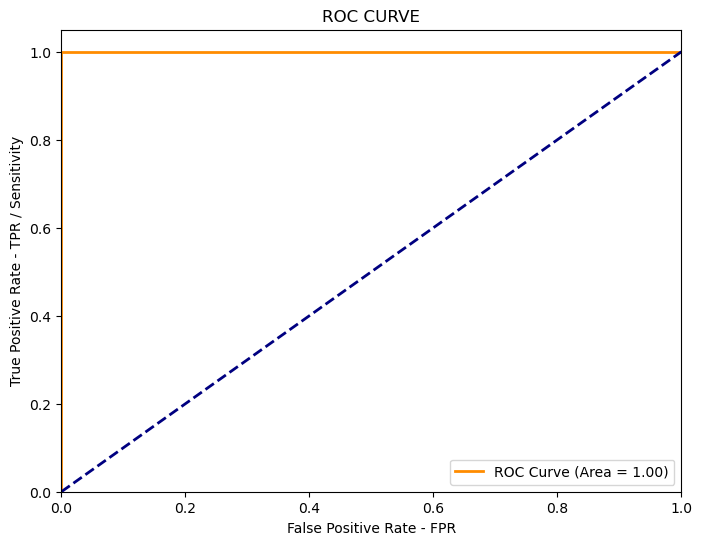

In [10]:
print("\n" + "="*70)
print("HYBRID APPROACH")
print("="*70)

full_dataset = RespiratoryDatasetLOO(resp_events, resp_labels, id_patients)
patient_ids = full_dataset.patients_ids

# get unique patient ids
unique_ids = np.unique(patient_ids)

results = []
results1 = []
results2 = []
results3 = []
loo = LeaveOneOut()


resp_combined = list(zip(resp_events, resp_feat))

# Assume X contains extracted features, y contains apnea labels (0 = normal, 1 = apnea)

X = resp_combined
y = resp_labels

for train_patient_indices, test_patient_index in loo.split(unique_ids):
    # Get patient IDs for training and testing
    train_patient_ids = unique_ids[train_patient_indices]
    test_patient_id = unique_ids[test_patient_index][0]  # Single ID for test

    # Get dataset indices for training and testing
    train_indices = [i for i, pid in enumerate(patient_ids) if pid in train_patient_ids]
    test_indices = [i for i, pid in enumerate(patient_ids) if pid == test_patient_id]

    # Get labels of training samples
    train_labels = [full_dataset[i][1] for i in train_indices]
    
    # Compute class weights for training set
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / class_counts
    train_sample_weights = [class_weights[label] for label in train_labels]
    # Create weighted sampler for training
    train_sampler = WeightedRandomSampler(weights=train_sample_weights, num_samples=len(train_indices), replacement=True)
    # Create DataLoaders
    train_dataset = Subset(full_dataset, train_indices)
    test_dataset = Subset(full_dataset, test_indices)
    train_loader = DataLoader(train_dataset, batch_size=128, sampler=train_sampler, collate_fn=collate_fn_loo)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, collate_fn=collate_fn_loo)
    print(f"Training on {len(train_indices)} samples, Testing on {len(test_indices)} samples (Patient {test_patient_id})")
    # Train and evaluate your model using train_loader and test_loader

    print('test Bilstm model')
    # MODEL SETUP
    bilstm_model = BILSTMModel(input_size=1).to(device)
    optimizer = optim.Adam(bilstm_model.parameters(), lr=0.0001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

    # Calculate weights for BCELoss
    class_0_count = class_counts[0]
    class_1_count = class_counts[1]
    # The weight for the minority class is the ratio of the majority class to the minority class
    pos_weight = torch.tensor([class_0_count / class_1_count]).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    file_path = 'bilstm_id{}.pth'.format(test_patient_id)
    if os.path.exists(file_path):
        bilstm_model.load_state_dict(torch.load(file_path, weights_only=True))
    else:
        print('ERROR: NO CHECKPOINT FOUND')

    # TESTING LOOP
    bilstm_model.eval()

    test_accuracy, y_pred, y_true, lstm_probs = evaluate_model(bilstm_model, test_loader, device)

    class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
    
    num_zeros = 0
    num_ones = 0

    for label in train_labels:
        if label == 0:
            num_zeros += 1
        elif label == 1:
            num_ones += 1

    # Calculate pos_weight
    if num_ones > 0:
        pos_weight = num_zeros / num_ones
    else:
        pos_weight = 1.0 

    y_train = train_labels
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}


    rf = RandomForestClassifier(class_weight=class_weight_dict, n_estimators=200, random_state=42, oob_score=True, min_samples_split=10, min_samples_leaf=1, max_features='log2', max_depth=20)
    xgb = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.01, scale_pos_weight=pos_weight, subsample=0.6, gamma=0.3, colsample_bytree=0.8)
    lgr = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced', C=np.float64(0.00407559644007287))
    lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')

    clf = VotingClassifier(estimators=[('rf', rf), ('xgb', xgb), ('lgr', lgr), ('lda', lda)], voting='soft') # ('svm', svm)], voting='soft')
    X_train_ml = [resp_feat[i] for i in train_indices]
  
    rf.fit(X_train_ml, y_train)
    xgb.fit(X_train_ml, y_train)
    lgr.fit(X_train_ml, y_train)
    lda.fit(X_train_ml, y_train)

    X_test_ml = [resp_feat[i] for i in test_indices]
    rf_probs = rf.predict_proba(X_test_ml)[:, 1]
    xgb_probs = xgb.predict_proba(X_test_ml)[:, 1]
    lgr_probs = lgr.predict_proba(X_test_ml)[:, 1]
    lda_probs = lda.predict_proba(X_test_ml)[:, 1]

    y_test = [resp_labels[i] for i in test_indices]

   
    print('###############hybrid approach ##################')

    # Combine these predictions to create the meta-features.
    meta_features = np.column_stack((rf_probs, xgb_probs, lgr_probs, lda_probs, lstm_probs))
    print(f"Meta-features shape: {meta_features.shape}")


    weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2]) # Esempio: pesi uguali per tutti i 5 modelli

    final_weighted_probs = np.average(meta_features, axis=1, weights=weights)
    best_thresh = find_best_threshold(y_test, final_weighted_probs, method='f1')
    print(f"Optimal threshold: {best_thresh:.4f}")
    y_pred = (np.array(final_weighted_probs) >= best_thresh).astype(int)

    metrics_dict = calculate_metrics(y_test, y_pred, final_weighted_probs)

    results.append({"patient_id": test_patient_id, 
                    "test_accuracy": metrics_dict['accuracy'], 
                    'tpr': metrics_dict['sensitivity'], 
                    'tnr': metrics_dict['specificity'], 
                    'ppv': metrics_dict['ppv'], 
                    'npv': metrics_dict['npv'], 
                    'auc-roc': metrics_dict['auc_roc'], 
                    'f1': metrics_dict['f1_score'], 
                    'pr_auc': metrics_dict['auc_pr']})

